In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
from math import sqrt
from datetime import datetime as dt

plt.rcParams.update(plt.rcParamsDefault)

col_width = 3.09 #inches

golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
fig_height = col_width*golden_mean # height in inches
figsize = (col_width, fig_height)

params = {'backend': 'ps',
          'axes.labelsize': 7, # was 10
          'axes.titlesize': 6,
          'axes.labelpad': 1, # was 4
          'xtick.major.pad': 3.5, # was 5.6
          'ytick.major.pad': 3.5, # was 5.6
          'grid.linestyle': ":",
          'font.size': 6, # was 10
          'legend.fontsize': 6, # was 10
          'legend.edgecolor': 'black',
          'legend.frameon': False,
          'legend.framealpha': 1, # was 0.2
          'legend.columnspacing': '1.5', # was 2
          'legend.borderpad': 0.2, # was 0.4
            'legend.handletextpad': 0.5, # was 0.8
            'legend.columnspacing': 1.2, # was 2
          'xtick.labelsize': 6,
          'ytick.labelsize': 6,
          'figure.figsize': [col_width,fig_height],
          'font.family': 'serif',
          'font.serif': 'Times',
          'patch.linewidth': 0.5,
}

matplotlib.rcParams.update(params)

%matplotlib inline
import pathlib
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import logging

plt.rcParams["font.serif"]     = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.family"]    = "serif"
plt.rcParams["axes.axisbelow"] = True
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

AGG_DIR     = pathlib.Path("../aggregated")
FIGURES_DIR = pathlib.Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Constants
BACKEND_ORDER  = ["null", "lattigo", "he3db", "patdiscover", "engorgio"]
SETUP_BACKEND_ORDER = ["null", "lattigo", "engorgio", "patdiscover", "he3db"]
BACKEND_LABELS = {"null": "Baseline",
                  "lattigo": "Lattigo",
                  "patdiscover": "PatDiscover",
                  "he3db": "HE3DB",
                  "engorgio": "Engorgio"}
BACKEND_COLORS = {"null": "#999999",
                  "lattigo": "#0072B2",
                  "patdiscover": "#CC79A7",
                  "he3db": "#D55E00",
                  "engorgio": "#009E73"}

QUERY_ORDER  = ["q1", "q2", "q3", "q4"]
QUERY_COLORS = {"q1": "#CC3311",   # red
                "q2": "#DDAA33",   # gold
                "q3": "#6A3D9A",   # purple
                "q4": "#8C510A"}   # brown

DATASET_ORDER  = ["mimic_iv", "nuclear_medicine", "hcup_nis"]
DATASET_LABELS = {"mimic_iv": "MIMIC",
                  "nuclear_medicine": "Nucl.",
                  "hcup_nis": "HCUP"}

ENTITY_ORDER  = ["researcher", "proxy", "provider", "patient"]
ENTITY_LABELS = {"researcher": "User",
                 "proxy": "Privacy Proxy",
                 "provider": "Data Provider",
                 "patient": "Patient"}
ENTITY_COLORS = {"researcher": "#332288",   # indigo
                 "proxy":      "#117777",   # deep teal
                 "provider":   "#882255",   # wine
                 "patient":    "#1A1A1A"}   # near-black

RUNTIME_PHASES = {
    "researcher": ["researcher-encrypt-query", "researcher-decrypt"],
    "proxy":      ["proxy-apply-ksk-literals", "proxy-cancellation",
                   "proxy-aggregate", "proxy-sum-results",
                   "proxy-bls-aggregate",
                   "proxy-bls-verify-aggregate"],
    "provider":   ["provider-evaluate"],
}
PHASE_COLORS = {
    "researcher-encrypt-query":   "#0072B2",
    "researcher-decrypt":         "#56B4E9",
    "proxy-apply-ksk-literals":   "#D55E00",
    "proxy-cancellation":         "#E69F00",
    "proxy-aggregate":            "#F0E442",
    "proxy-sum-results":          "#DDCC77",
    "proxy-bls-aggregate":        "#CC79A7",
    "proxy-bls-verify-aggregate": "#882255",
    "provider-evaluate":          "#009E73",
    "other":                      "#BBBBBB",
}
PHASE_LABELS = {
    "researcher-encrypt-query":   "Encrypt Query",
    "researcher-decrypt":         "Decrypt",
    "proxy-apply-ksk-literals":   "KSK Literals",
    "proxy-cancellation":         "Cancellation",
    "proxy-aggregate":            "Key Switch",
    "proxy-sum-results":          "Aggregate",
    "proxy-bls-aggregate":        "BLS Aggregate",
    "proxy-bls-verify-aggregate": "BLS Verify",
    "provider-evaluate":          "Evaluate",
    "other":                      "Other / overhead",
}

In [ ]:
# generate via "./fecad bench aggregate"
agg = pd.read_csv(AGG_DIR / "aggregate.csv")
agg["backend"] = agg["backend"].fillna("null")   # 'null' is parsed as NaN

# compatibility with old data
E2E_PHASE = ("researcher-query-total" if "researcher-query-total" in set(agg["phase"]) else "proxy-query-total")

# median and quartiles of query completion time
def latency(exp, dims):
    sub = agg[(agg["experiment"] == exp) & (agg["phase"] == E2E_PHASE)]
    return (sub[dims + ["duration_median", "duration_q25", "duration_q75", "n"]]
            .rename(columns={"duration_median": "med",
                             "duration_q25": "q25", "duration_q75": "q75"})
            .reset_index(drop=True))

# median duration of each runtime phase
def phase_durations(exp, dims):
    keep = [p for ps in RUNTIME_PHASES.values() for p in ps]
    sub = agg[(agg["experiment"] == exp) & (agg["phase"].isin(keep))]
    return sub[dims + ["entity_type", "phase", "duration_median"]].reset_index(drop=True)

print(f"aggregate.csv: {len(agg):,} groups, E2E phase {E2E_PHASE}")

from IPython.display import Markdown, display

task_params = pd.read_csv(AGG_DIR / "params.csv")
task_params["backend"] = task_params["backend"].fillna("null")
print(f"params.csv: {len(task_params):,} completed tasks")

def _fmt(field, vals):
    if field == "records":
        return ", ".join(f"{int(v):,}" for v in vals)
    if field == "consent_fraction":
        return ", ".join(f"{float(v):g}" for v in vals)
    return ", ".join(str(v) for v in vals)

# settings of the plotted runs, below the figure
def show_settings(experiment, prefix=None, **plot_filters):
    sub = task_params[task_params["experiment"] == experiment].copy()
    for k, v in plot_filters.items():
        if k in sub.columns:
            sub = sub[sub[k] == v]
    fields = ("dataset", "records", "n_providers", "consent_fraction", "query", "backend")
    parts = []
    for f in fields:
        if f not in sub.columns:
            continue
        vals = sorted({v for v in sub[f].dropna().tolist() if v != ""}, key=str)
        if vals:
            parts.append(f"**{f}**: {_fmt(f, vals)}")
    head = f"**{prefix}**: " if prefix else f"**{experiment.upper()}**: "
    display(Markdown(head + "; ".join(parts)))

aggregate.csv: 3,515 groups, E2E phase researcher-query-total
params.csv: 1,088 completed tasks


/tmp/ipykernel_3120309/3051502783.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


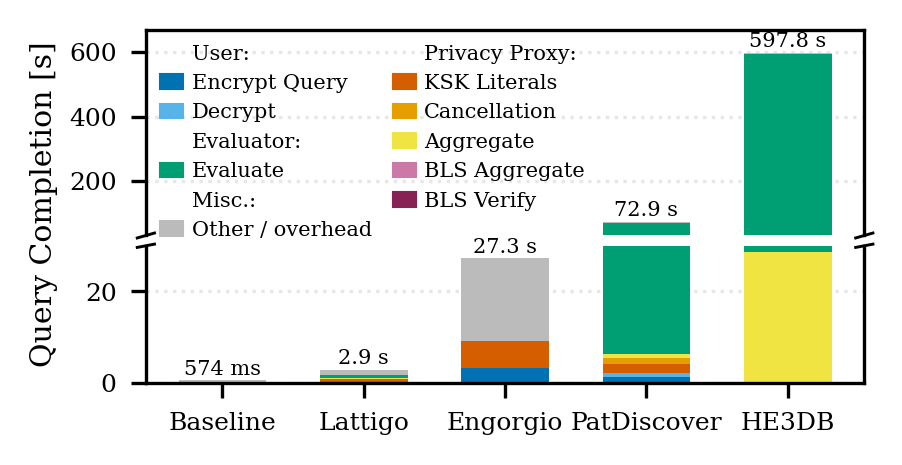

**backend_comparison**: 

In [ ]:
# backend_comparison: per-query phases per backend (E1, q1)
# time not covered by a phase is drawn as "other"
# broken y-axis so Engorgio and HE3DB do not flatten the rest
rt  = phase_durations("e1", ["backend", "query"])
rt  = rt[rt["query"] == "q1"]
lat = latency("e1", ["backend", "query"])
lat = lat[lat["query"] == "q1"].set_index("backend")["med"]
backends = [b for b in BACKEND_ORDER if b in rt["backend"].values]

BREAK = 30.0   # seconds

fig, (axU, axL_) = plt.subplots(
    2, 1, sharex=True, dpi=300,
    figsize=(col_width, fig_height*0.8),
    gridspec_kw={"height_ratios": [0.7, 0.3], "hspace": 0.06},
)

def _draw_bars(ax):
    for i, bk in enumerate(backends):
        sub, bot = rt[rt["backend"] == bk], 0.0
        for ent in ("researcher", "proxy", "provider"):
            for ph in RUNTIME_PHASES[ent]:
                row = sub[(sub["entity_type"] == ent) & (sub["phase"] == ph)]
                val = float(row["duration_median"].iloc[0]) if not row.empty else 0.0
                if val <= 0:
                    continue
                ax.bar(i, val, 0.62, bottom=bot, color=PHASE_COLORS[ph], edgecolor="none")
                bot += val
        # residual, e.g. he3db has no proxy-aggregate timer
        e2e = float(lat.get(bk, 0.0))
        resid = e2e - bot
        if resid > 0:
            ax.bar(i, resid, 0.62, bottom=bot, color=PHASE_COLORS["other"], edgecolor="none")

_draw_bars(axU)
_draw_bars(axL_)

# headroom for the total labels
ymax = max(float(lat.get(bk, 0.0)) for bk in backends) * 1.12
axU.set_ylim(BREAK, ymax)
axL_.set_ylim(0, BREAK)

def _fmt_total(v):
    return f"{v*1000:.0f} ms" if v < 1.0 else f"{v:.1f} s"

for i, bk in enumerate(backends):
    total = float(lat.get(bk, 0.0))
    if total <= 0:
        continue
    ax = axU if total > BREAK else axL_
    off = (ymax - BREAK) * 0.01 if ax is axU else BREAK * 0.01
    ax.text(i, total + off, _fmt_total(total),
            ha="center", va="bottom", fontsize=5)

# break marks
axU.spines["bottom"].set_visible(False)
axL_.spines["top"].set_visible(False)
axU.tick_params(labelbottom=False, bottom=False)
d = 0.012   # mark size in axis fraction
kw = dict(transform=axU.transAxes, color="k", clip_on=False, lw=0.7)
axU.plot((-d, +d), (-d, +d), **kw)
axU.plot((1 - d, 1 + d), (-d, +d), **kw)
kw["transform"] = axL_.transAxes
axL_.plot((-d, +d), (1 - d, 1 + d), **kw)
axL_.plot((1 - d, 1 + d), (1 - d, 1 + d), **kw)

axL_.set_xticks(range(len(backends)))
axL_.set_xticklabels([BACKEND_LABELS[b] for b in backends])
# one y-label for both panes
fig.supylabel("Query Completion [s]", x=0.0)
for ax in (axU, axL_):
    ax.grid(True, axis="y", alpha=0.3); ax.grid(axis="x", visible=False)

# legend columns: user, evaluator and misc in the first, proxy in the second
def _block(ent, header):
    if ent == "__other__":
        return [Patch(alpha=0, label=header),
                Patch(color=PHASE_COLORS["other"], label=PHASE_LABELS["other"])]
    block = [Patch(alpha=0, label=header)]
    for ph in RUNTIME_PHASES[ent]:
        block.append(Patch(color=PHASE_COLORS[ph], label=PHASE_LABELS[ph]))
    return block

columns = [
    _block("researcher", "User:") + _block("provider", "Evaluator:") +  _block("__other__",  "Misc.:"),
    _block("proxy",      "Privacy Proxy:"),
]
n_rows = max(len(c) for c in columns)
for c in columns:
    while len(c) < n_rows:
        c.append(Patch(alpha=0, label=""))

handles = [h for c in columns for h in c]
axU.legend(handles=handles, ncol=len(columns), loc="upper left",
           bbox_to_anchor=(0, 1), fontsize=5,
           handlelength=1.1, columnspacing=1.0, handletextpad=0.4)

fig.tight_layout(pad=0.3)
fig.savefig(FIGURES_DIR / "backend_comparison.pdf", bbox_inches="tight")
plt.show()
show_settings("e1", prefix="backend_comparison", query="q2")

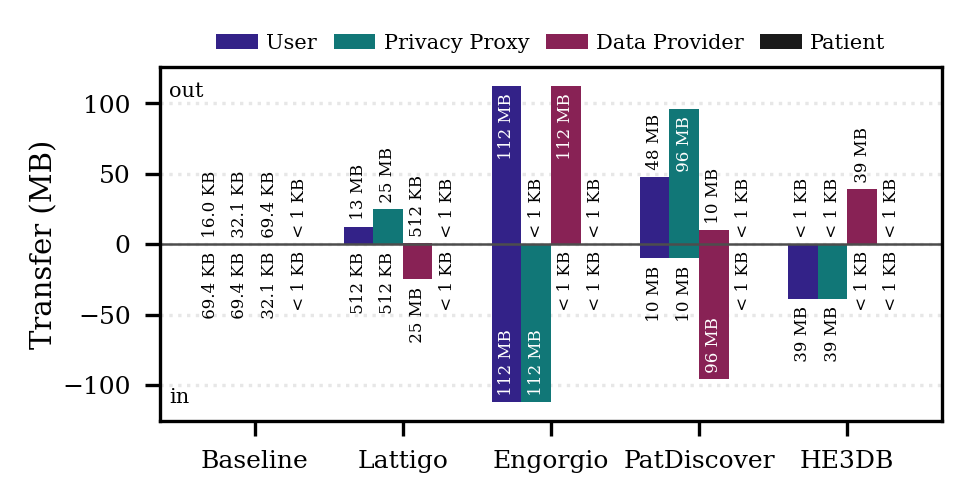

**system**: **dataset**: mimic_iv; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1; **backend**: engorgio, he3db, lattigo, null, patdiscover

In [ ]:
# system: per-query communication per entity (E1, q1)
# out above zero, in below; setup traffic is in system_setup
# only the listed phases count, other rows in aggregate.csv are on-disk sizes
# the patient bar is the cost of a single patient
src = agg[(agg["experiment"] == "e1") & (agg["query"] == "q1")].copy()
if "net_out_bytes_mean" not in src.columns:
    src["net_out_bytes_mean"] = src["network_bytes_mean"]
    src["net_in_bytes_mean"]  = 0.0

# engorgio e1/q1 tasks in aggregated/ fail at FHE eval, so its bytes come from
# the same configuration in aggregated2/
try:
    agg_old = pd.read_csv(AGG_DIR.parent / "aggregated2" / "aggregate.csv")
    agg_old["backend"] = agg_old["backend"].fillna("null")
    old_q1 = agg_old[(agg_old["experiment"] == "e1") & (agg_old["query"] == "q1")
                     & (agg_old["backend"] == "engorgio")].copy()
    if "net_out_bytes_mean" not in old_q1.columns:
        old_q1["net_out_bytes_mean"] = old_q1.get("network_bytes_mean", 0.0)
        old_q1["net_in_bytes_mean"]  = 0.0
    missing_phases = {"researcher-decrypt", "proxy-provider-eval"}
    have = set(src[src["backend"] == "engorgio"]["phase"])
    fallback_rows = old_q1[old_q1["phase"].isin(missing_phases) & ~old_q1["phase"].isin(have)]
    # provider-evaluate is proxy-provider-eval with out and in swapped
    ppe_row = old_q1[old_q1["phase"] == "proxy-provider-eval"]
    if not ppe_row.empty and "engorgio" not in set(
            src[(src["phase"] == "provider-evaluate")]["backend"]):
        synth = ppe_row.copy()
        synth["entity_type"] = "provider"
        synth["phase"] = "provider-evaluate"
        synth["net_out_bytes_mean"], synth["net_in_bytes_mean"] = (
            ppe_row["net_in_bytes_mean"].values, ppe_row["net_out_bytes_mean"].values,
        )
        fallback_rows = pd.concat([fallback_rows, synth], ignore_index=True)
    if not fallback_rows.empty:
        # align columns: drop any aggregated2 columns absent from src
        keep = [c for c in src.columns if c in fallback_rows.columns]
        src = pd.concat([src, fallback_rows[keep]], ignore_index=True)
except FileNotFoundError:
    pass

# (phase, source entity, out field, in field) per entity
COMM_QUERY_PHASES = {
    "researcher": [
        ("researcher-encrypt-query",  "researcher", "net_out_bytes_mean", "net_in_bytes_mean"),
        ("researcher-decrypt",        "researcher", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "proxy": [
        ("proxy-provider-eval",       "proxy", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "provider": [
        ("provider-evaluate",         "provider", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "patient": [
        ("patient-consent",           "patient",  "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
}

PATIENT_SCALE = 1  # one patient, not the cohort

# MB one entity sends (out) or receives (in)
def _bytes_for(src_df, phase_map, bk, entity, direction, patient_scale=1.0):
    total = 0.0
    for phase, src_ent, out_field, in_field in phase_map[entity]:
        row = src_df[(src_df["backend"] == bk)
                     & (src_df["entity_type"] == src_ent)
                     & (src_df["phase"] == phase)]
        if row.empty:
            continue
        field = out_field if direction == "out" else in_field
        val = float(row[field].sum())
        if entity == "patient":
            val *= patient_scale
        total += val
    return total / 1024**2

# bar chart shared by system and system_setup
def _draw_comm_fig(src_df, phase_map, entity_order, entity_labels, entity_colors,
                   backends, out_path, patient_scale=1.0):
    x      = np.arange(len(backends))
    width  = 0.8 / len(entity_order)
    shifts = (np.arange(len(entity_order)) - (len(entity_order) - 1) / 2) * width

    fig, axB = plt.subplots(figsize=(col_width, fig_height * 0.8), dpi=300)

    out_vals = {ent: [ _bytes_for(src_df, phase_map, b, ent, "out", patient_scale) for b in backends] for ent in entity_order}
    in_vals  = {ent: [-_bytes_for(src_df, phase_map, b, ent, "in",  patient_scale) for b in backends] for ent in entity_order}
    out_max  = max((v for vs in out_vals.values() for v in vs), default=0.0)
    in_min   = min((v for vs in in_vals.values()  for v in vs), default=0.0)

    for j, ent in enumerate(entity_order):
        axB.bar(x + shifts[j], out_vals[ent], width, color=entity_colors[ent], label=entity_labels[ent], edgecolor="none")
        axB.bar(x + shifts[j], in_vals[ent],  width, color=entity_colors[ent], edgecolor="none")

    def _fmt(v):
        a = abs(v)
        if a >= 2048:    return f" {a/1024:.0f} GB "
        if a >= 1024:    return f" {a/1024:.1f} GB "
        if a >= 10:      return f" {a:.0f} MB "
        if a >= 1:       return f" {a:.1f} MB "
        if a >= 0.1:     return f" {a*1024:.0f} KB "
        if a >= 0.01:    return f" {a*1024:.1f} KB "
        return f" < 1 KB "

    out_off = max(out_max, 1.0) * 0.01
    in_off  = max(abs(in_min), 1.0) * 0.01
    # label every bar; zero and missing both read "< 1 KB" as the bench cannot
    # tell them apart
    for j, ent in enumerate(entity_order):
        for i, v in enumerate(out_vals[ent]):
            xpos = x[i] + shifts[j]
            if v >= 0.8 * out_max and out_max > 0:
                axB.text(xpos, v - out_off, _fmt(v), ha="right", va="center", fontsize=4, color="white", rotation=90, rotation_mode="anchor")
            else:
                axB.text(xpos, max(v, 0) + out_off, _fmt(v), ha="left", va="center", fontsize=4, color="black", rotation=90, rotation_mode="anchor")
        for i, v in enumerate(in_vals[ent]):
            xpos = x[i] + shifts[j]
            if v <= 0.8 * in_min and in_min < 0:
                axB.text(xpos, v + in_off, _fmt(v), ha="left", va="center", fontsize=4, color="white", rotation=90, rotation_mode="anchor")
            else:
                axB.text(xpos, min(v, 0) - in_off, _fmt(v), ha="right", va="center", fontsize=4, color="black", rotation=90, rotation_mode="anchor")

    axB.set_ylabel("Transfer (MB)")
    axB.axhline(0, color="0.3", lw=0.6)
    axB.text(0.012, 0.96, "out", transform=axB.transAxes, va="top", fontsize=5)
    axB.text(0.012, 0.04, "in",  transform=axB.transAxes, va="bottom", fontsize=5)
    axB.set_xticks(x); axB.set_xticklabels([BACKEND_LABELS[b] for b in backends])
    axB.grid(True, axis="y", alpha=0.3); axB.grid(axis="x", visible=False)
    axB.legend(ncol=len(entity_order), loc="lower center", bbox_to_anchor=(0.5, 1.0),
               columnspacing=0.8, handletextpad=0.4, fontsize=5)

    ymax_plot = max(out_max, abs(in_min)) * 1.12
    if ymax_plot > 0:
        axB.set_ylim(-ymax_plot if in_min < 0 else 0, ymax_plot if out_max > 0 else 0)
    fig.tight_layout(pad=0.3)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

backends = [b for b in BACKEND_ORDER if b in src["backend"].values]
_draw_comm_fig(
    src, COMM_QUERY_PHASES,
    entity_order=["researcher", "proxy", "provider", "patient"],
    entity_labels=ENTITY_LABELS,
    entity_colors=ENTITY_COLORS,
    backends=backends,
    out_path=FIGURES_DIR / "system.pdf",
    patient_scale=PATIENT_SCALE,
)
show_settings("e1", prefix="system", query="q1")

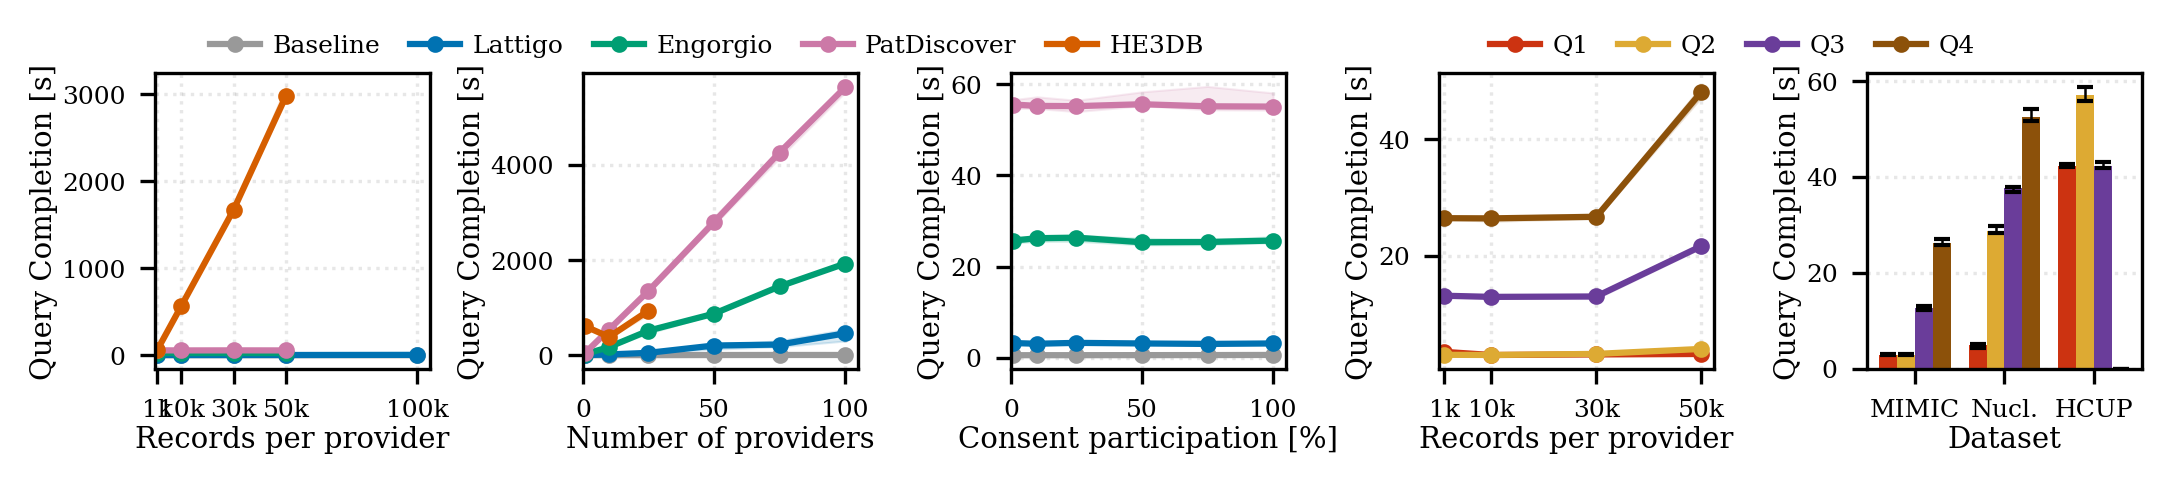

**scalability (1: records, Q1)**: **dataset**: mimic_iv; **records**: 1,000, 10,000, 100,000, 1,000,000, 250,000, 30,000, 50,000, 500,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1; **backend**: engorgio, he3db, lattigo, null, patdiscover

**scalability (2: providers)**: **dataset**: mimic_iv; **records**: 100, 1,000, 10,000, 133, 200, 400; **n_providers**: 1, 10, 100, 25, 50, 75; **consent_fraction**: 1; **query**: q2; **backend**: engorgio, he3db, lattigo, null, patdiscover

**scalability (3: consent)**: **dataset**: mimic_iv; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 0.01, 0.1, 0.25, 0.5, 0.75, 1; **query**: q2; **backend**: engorgio, lattigo, null, patdiscover

**scalability (4: records, Lattigo)**: **dataset**: mimic_iv; **records**: 1,000, 10,000, 100,000, 30,000, 50,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1, q2, q3, q4; **backend**: lattigo

**scalability (5: datasets, Lattigo)**: **dataset**: hcup_nis, mimic_iv, nuclear_medicine; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1, q2, q3, q4; **backend**: lattigo

In [ ]:
# scalability, five panels
#   axM  records, per backend (q1)
#   axR  providers, per backend
#   axC  consent, per backend (E5)
#   axL  records, per query (Lattigo)
#   axD  datasets, per query (Lattigo)
fig, (axM, axR, axC, axL, axD) = plt.subplots(1, 5, figsize=(col_width*2.3, fig_height*0.7), dpi=300)

# 1: records per provider, up to 100k
SCALE_QUERY = "q1"
e2 = latency("e2", ["backend", "query", "records"])
e2M = e2[e2["query"] == SCALE_QUERY][["backend", "records", "med", "q25", "q75"]].copy()
e2M["records"] = e2M["records"].astype(int)
e2M = e2M[e2M["records"] <= 100000]
scaleM = e2M.sort_values(["backend", "records"]).reset_index(drop=True)

for bk in [b for b in BACKEND_ORDER if b in scaleM["backend"].values]:
    sub = scaleM[scaleM["backend"] == bk].sort_values("records")
    if sub.empty:
        continue
    axM.plot(sub["records"], sub["med"], "o-", ms=3, color=BACKEND_COLORS[bk], label=BACKEND_LABELS[bk])
    axM.fill_between(sub["records"], sub["q25"], sub["q75"], color=BACKEND_COLORS[bk], alpha=0.15)
axM.set_xlabel("Records per provider"); axM.set_ylabel("Query Completion [s]")
axM.set_xticks(sorted(scaleM["records"].dropna().unique()))
axM.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
axM.set_xlim(0)
axM.grid(True, alpha=0.3)

# 2: number of providers
e3 = latency("e3", ["backend", "n_providers"])
for bk in [b for b in BACKEND_ORDER if b in e3["backend"].values]:
    sub = e3[e3["backend"] == bk].sort_values("n_providers")
    if sub.empty:
        continue
    axR.plot(sub["n_providers"], sub["med"], "o-", ms=3, color=BACKEND_COLORS[bk], label=BACKEND_LABELS[bk])
    axR.fill_between(sub["n_providers"], sub["q25"], sub["q75"], color=BACKEND_COLORS[bk], alpha=0.15)
axR.set_xlabel("Number of providers"); axR.set_ylabel("Query Completion [s]")
axR.set_xlim(0)
axR.grid(True, alpha=0.3)

# 3: consent participation
e5 = latency("e5", ["backend", "consent_fraction"])
for bk in [b for b in BACKEND_ORDER if b in e5["backend"].values]:
    sub = e5[e5["backend"] == bk].sort_values("consent_fraction")
    if sub.empty:
        continue
    pct = sub["consent_fraction"] * 100
    axC.plot(pct, sub["med"], "o-", ms=3, color=BACKEND_COLORS[bk], label=BACKEND_LABELS[bk])
    axC.fill_between(pct, sub["q25"], sub["q75"], color=BACKEND_COLORS[bk], alpha=0.15)
axC.set_xlabel("Consent participation [%]"); axC.set_ylabel("Query Completion [s]")
axC.set_xlim(0)
axC.grid(True, alpha=0.3)

# 4: records per provider, per query
e2L = e2[(e2["backend"] == "lattigo") & (e2["records"] < 100000)]
for q in QUERY_ORDER:
    sub = e2L[e2L["query"] == q].sort_values("records")
    if sub.empty:
        continue
    axL.plot(sub["records"], sub["med"], "o-", ms=3, color=QUERY_COLORS[q], label=f"Q{q[1]}")
    axL.fill_between(sub["records"], sub["q25"], sub["q75"], color=QUERY_COLORS[q], alpha=0.15)
axL.set_xlabel("Records per provider"); axL.set_ylabel("Query Completion [s]")
axL.set_xticks(sorted(e2L["records"].dropna().unique()))
axL.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
axL.set_xlim(0)
axL.grid(True, alpha=0.3)

# 5: datasets, per query
e4 = latency("e4", ["backend", "dataset", "query"])
e4 = e4[e4["backend"] == "lattigo"]
datasets = [d for d in DATASET_ORDER if d in e4["dataset"].values]
queries  = [q for q in QUERY_ORDER  if q in e4["query"].values]
nq      = max(len(queries), 1)
bwidth  = 0.8 / nq
shifts  = (np.arange(nq) - (nq - 1) / 2) * bwidth
xd      = np.arange(len(datasets))
for j, q in enumerate(queries):
    rows = [e4[(e4["dataset"] == d) & (e4["query"] == q)] for d in datasets]
    meds = [float(r["med"].sum()) for r in rows]
    q25s = [float(r["q25"].sum()) for r in rows]
    q75s = [float(r["q75"].sum()) for r in rows]
    yerr = np.clip([np.subtract(meds, q25s), np.subtract(q75s, meds)], 0, None)
    axD.bar(xd + shifts[j], meds, bwidth, yerr=yerr, color=QUERY_COLORS[q], error_kw={"lw": 0.6, "capsize": 2}, edgecolor="none")
axD.set_xticks(xd)
axD.set_xticklabels([DATASET_LABELS[d] for d in datasets])
axD.set_xlabel("Dataset")
axD.set_ylabel("Query Completion [s]")
axD.grid(True, axis="y", alpha=0.3)
axD.grid(axis="x", visible=False)

# backend legend above panels 1 to 3, query legend above 4 and 5, same height
def _legend_above(handles, ax_a, ax_b, x_offset=0):
    bba = ax_a.get_position(); bbb = ax_b.get_position()
    x_mid = (bba.x0 + bbb.x1) / 2
    y_top = max(bba.y1, bbb.y1) * 1.1
    fig.legend(handles=handles, ncol=len(handles), loc="lower center", bbox_to_anchor=(x_mid + x_offset, y_top))

backends_shared = [b for b in BACKEND_ORDER
                   if b in set(scaleM["backend"].values) | set(e3["backend"].values) | set(e5["backend"].values)]
if backends_shared:
    bk_handles = [plt.Line2D([0], [0], marker="o", ms=3,
                              color=BACKEND_COLORS[b], label=BACKEND_LABELS[b])
                  for b in backends_shared]
    _legend_above(bk_handles, axM, axC, x_offset=-0.03)

queries_shared = [q for q in QUERY_ORDER
                  if q in set(e2L["query"].values) | set(queries)]
if queries_shared:
    q_handles = [plt.Line2D([0], [0], marker="o", ms=3, color=QUERY_COLORS[q], label=f"Q{q[1]}") for q in queries_shared]
    _legend_above(q_handles, axL, axD ,x_offset=0.05)

fig.tight_layout(pad=0.4)
fig.savefig(FIGURES_DIR / "scalability.pdf", bbox_inches="tight")
plt.show()
show_settings("e2", prefix="scalability (1: records, Q1)", query="q1")
show_settings("e3", prefix="scalability (2: providers)")
show_settings("e5", prefix="scalability (3: consent)")
show_settings("e2", prefix="scalability (4: records, Lattigo)", backend="lattigo")
show_settings("e4", prefix="scalability (5: datasets, Lattigo)", backend="lattigo")

/tmp/ipykernel_3120309/3633433805.py:142: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.3)


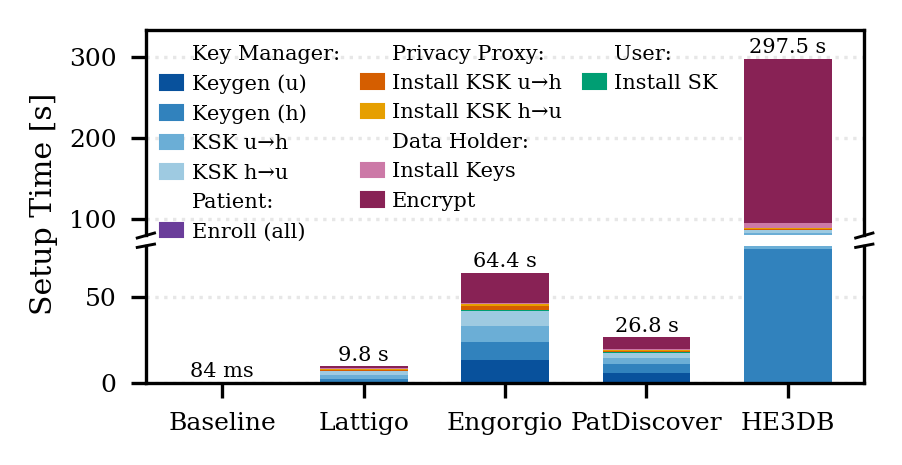

**setup_comparison**: **dataset**: mimic_iv; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1; **backend**: engorgio, he3db, lattigo, null, patdiscover

In [ ]:
# setup_comparison: one-time setup phases per backend (E1, q1)
# patient-enroll covers all consenting patients, not one
# patient-consent recurs per query and is excluded
SETUP_PHASES = {
    "keymanager": ["km-keygen-researcher", "km-keygen-provider", "km-ksk-LtoR", "km-ksk-RtoL"],
    "researcher": ["researcher-install-sk"],
    "proxy":      ["proxy-install-ksk-LtoR", "proxy-install-ksk-RtoL"],
    "provider":   ["provider-install-keys", "provider-encrypt"],
    "patient":    ["patient-enroll"],
}
SETUP_PHASE_COLORS = {
    "km-keygen-researcher":   "#08519C",
    "km-keygen-provider":     "#3182BD",
    "km-ksk-LtoR":            "#6BAED6",
    "km-ksk-RtoL":            "#9ECAE1",
    "researcher-install-sk":  "#009E73",
    "proxy-install-ksk-LtoR": "#D55E00",
    "proxy-install-ksk-RtoL": "#E69F00",
    "provider-install-keys":  "#CC79A7",
    "provider-encrypt":       "#882255",
    "patient-enroll":         "#6A3D9A",
}
SETUP_PHASE_LABELS = {
    "km-keygen-researcher":   "Keygen (u)",
    "km-keygen-provider":     "Keygen (h)",
    "km-ksk-LtoR":            "KSK u→h",
    "km-ksk-RtoL":            "KSK h→u",
    "researcher-install-sk":  "Install SK",
    "proxy-install-ksk-LtoR": "Install KSK u→h",
    "proxy-install-ksk-RtoL": "Install KSK h→u",
    "provider-install-keys":  "Install Keys",
    "provider-encrypt":       "Encrypt",
    "patient-enroll":         "Enroll (all)",
}
SETUP_ENTITY_HEADERS = {
    "keymanager": "Key Manager:",
    "researcher": "User:",
    "proxy":      "Privacy Proxy:",
    "provider":   "Data Holder:",
    "patient":    "Patient:",
}

keep = [p for ps in SETUP_PHASES.values() for p in ps]
st  = agg[(agg["experiment"] == "e1") & (agg["query"] == "q1") & (agg["phase"].isin(keep))][
    ["backend", "entity_type", "phase", "duration_median"]].reset_index(drop=True)
backends = [b for b in SETUP_BACKEND_ORDER if b in st["backend"].values]

# broken y-axis: patient-enroll dominates patdiscover and lattigo
totals = st.groupby("backend")["duration_median"].sum()
BREAK = 80.0
ymax  = float(totals.max()) * 1.12

fig, (axU, axL_) = plt.subplots(
    2, 1, sharex=True, dpi=300,
    figsize=(col_width, fig_height * 0.8),
    gridspec_kw={"height_ratios": [0.6, 0.4], "hspace": 0.06},
)

def _draw_bars(ax):
    for i, bk in enumerate(backends):
        sub, bot = st[st["backend"] == bk], 0.0
        for ent, phases in SETUP_PHASES.items():
            for ph in phases:
                row = sub[(sub["entity_type"] == ent) & (sub["phase"] == ph)]
                val = float(row["duration_median"].iloc[0]) if not row.empty else 0.0
                if val <= 0:
                    continue
                ax.bar(i, val, 0.62, bottom=bot, color=SETUP_PHASE_COLORS[ph], edgecolor="none")
                bot += val

_draw_bars(axU)
_draw_bars(axL_)

axU.set_ylim(BREAK, ymax)
axL_.set_ylim(0, BREAK)

def _fmt_total(v):
    return f"{v*1000:.0f} ms" if v < 1.0 else f"{v:.1f} s"

for i, bk in enumerate(backends):
    total = float(totals.get(bk, 0.0))
    if total <= 0:
        continue
    ax = axU if total > BREAK else axL_
    off = (ymax - BREAK) * 0.01 if ax is axU else BREAK * 0.01
    ax.text(i, total + off, _fmt_total(total), ha="center", va="bottom", fontsize=5)

axU.spines["bottom"].set_visible(False)
axL_.spines["top"].set_visible(False)
axU.tick_params(labelbottom=False, bottom=False)
d = 0.012
kw = dict(transform=axU.transAxes, color="k", clip_on=False, lw=0.7)
axU.plot((-d, +d), (-d, +d), **kw)
axU.plot((1 - d, 1 + d), (-d, +d), **kw)
kw["transform"] = axL_.transAxes
axL_.plot((-d, +d), (1 - d, 1 + d), **kw)
axL_.plot((1 - d, 1 + d), (1 - d, 1 + d), **kw)

axL_.set_xticks(range(len(backends)))
axL_.set_xticklabels([BACKEND_LABELS[b] for b in backends])
fig.supylabel("Setup Time [s]", x=0.0)
for ax in (axU, axL_):
    ax.grid(True, axis="y", alpha=0.3); ax.grid(axis="x", visible=False)

# legend columns, padded to the tallest
def _block(ent):
    block = [Patch(alpha=0, label=SETUP_ENTITY_HEADERS[ent])]
    for ph in SETUP_PHASES[ent]:
        block.append(Patch(color=SETUP_PHASE_COLORS[ph],
                           label=SETUP_PHASE_LABELS[ph]))
    return block

columns = [
    _block("keymanager") + _block("patient"),
    _block("proxy") + _block("provider"),
    _block("researcher")
]
n_rows = max(len(c) for c in columns)
for c in columns:
    while len(c) < n_rows:
        c.append(Patch(alpha=0, label=""))

handles = [h for c in columns for h in c]
axU.legend(handles=handles, ncol=len(columns), loc="upper left",
           bbox_to_anchor=(0, 1), fontsize=5,
           handlelength=1.1, columnspacing=1.0, handletextpad=0.4)

fig.tight_layout(pad=0.3)
fig.savefig(FIGURES_DIR / "setup_comparison.pdf", bbox_inches="tight")
plt.show()


show_settings("e1", prefix="setup_comparison", query="q1")

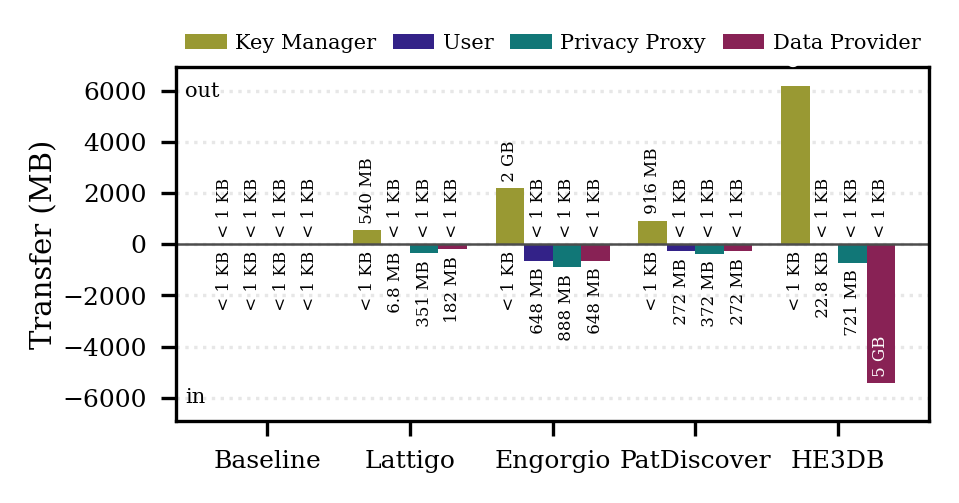

**system_setup**: **dataset**: mimic_iv; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 1; **query**: q1; **backend**: engorgio, he3db, lattigo, null, patdiscover

In [ ]:
# system_setup: one-time key distribution traffic (E1, q1)
COMM_SETUP_PHASES = {
    "keymanager": [
        ("km-send-researcher-sk", "keymanager", "net_out_bytes_mean", "net_in_bytes_mean"),
        ("km-send-provider-sk",   "keymanager", "net_out_bytes_mean", "net_in_bytes_mean"),
        ("km-send-ksk-LtoR",      "keymanager", "net_out_bytes_mean", "net_in_bytes_mean"),
        ("km-send-ksk-RtoL",      "keymanager", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "researcher": [
        ("researcher-install-sk",  "researcher", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "proxy": [
        ("proxy-install-ksk-LtoR", "proxy", "net_out_bytes_mean", "net_in_bytes_mean"),
        ("proxy-install-ksk-RtoL", "proxy", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
    "provider": [
        ("provider-install-keys",  "provider", "net_out_bytes_mean", "net_in_bytes_mean"),
    ],
}

SETUP_ENTITY_ORDER  = ["keymanager", "researcher", "proxy", "provider"]
SETUP_ENTITY_LABELS = {
    "keymanager": "Key Manager",
    "researcher": ENTITY_LABELS["researcher"],
    "proxy":      ENTITY_LABELS["proxy"],
    "provider":   ENTITY_LABELS["provider"],
}
SETUP_ENTITY_COLORS = {
    "keymanager": "#999933",   # olive
    "researcher": ENTITY_COLORS["researcher"],
    "proxy":      ENTITY_COLORS["proxy"],
    "provider":   ENTITY_COLORS["provider"],
}

backends_setup = [b for b in SETUP_BACKEND_ORDER if b in src["backend"].values]
_draw_comm_fig(
    src, COMM_SETUP_PHASES,
    entity_order=SETUP_ENTITY_ORDER,
    entity_labels=SETUP_ENTITY_LABELS,
    entity_colors=SETUP_ENTITY_COLORS,
    backends=backends_setup,
    out_path=FIGURES_DIR / "system_setup.pdf",
)
show_settings("e1", prefix="system_setup", query="q1")

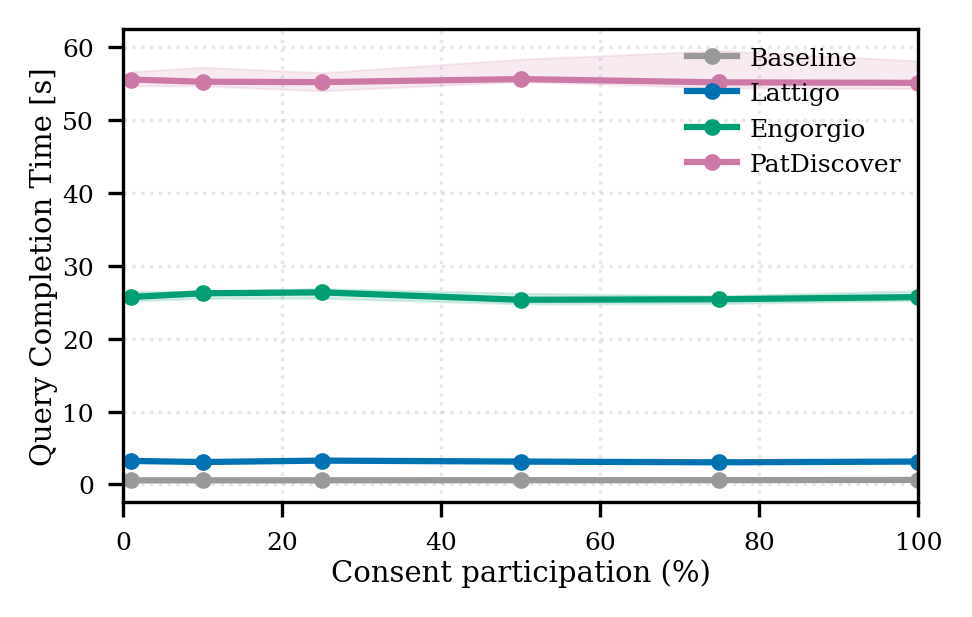

**consent**: **dataset**: mimic_iv; **records**: 10,000; **n_providers**: 1; **consent_fraction**: 0.01, 0.1, 0.25, 0.5, 0.75, 1; **query**: q2; **backend**: engorgio, lattigo, null, patdiscover

In [ ]:
# consent: query completion time vs consent participation (E5)
# mimic_iv, q2, 100k records, one provider
e5 = latency("e5", ["backend", "consent_fraction"])

fig, ax = plt.subplots(figsize=(col_width, fig_height), dpi=300)
for bk in [b for b in BACKEND_ORDER if b in e5["backend"].values]:
    sub = e5[e5["backend"] == bk].sort_values("consent_fraction")
    if sub.empty:
        continue
    pct = sub["consent_fraction"] * 100
    ax.plot(pct, sub["med"], "o-", ms=3,
            color=BACKEND_COLORS[bk], label=BACKEND_LABELS[bk])
    ax.fill_between(pct, sub["q25"], sub["q75"],
                    color=BACKEND_COLORS[bk], alpha=0.15)

ax.set_xlabel("Consent participation (%)"); ax.set_ylabel("Query Completion Time [s]")
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
if ax.get_legend_handles_labels()[0]:
    ax.legend()

fig.tight_layout(pad=0.3)
fig.savefig(FIGURES_DIR / "consent.pdf", bbox_inches="tight")
plt.show()
show_settings("e5", prefix="consent")

# TODO integrate this into scalability figure too.

In [ ]:
# summary tables, in paper order

def _qct(exp, **f):  # query completion time rows for one experiment
    s = agg[(agg["experiment"] == exp) & (agg["phase"] == "researcher-query-total")].copy()
    s["backend"] = s["backend"].fillna("null")
    for k, v in f.items():
        s = s[(s[k] - v).abs() < 1e-6] if k == "consent_fraction" else s[s[k] == v]
    return s

def _show(t, title):
    t = t[["duration_mean", "duration_median", "n"]].round(1)
    t.columns = ["mean [s]", "median [s]", "runs"]
    print(f"\n{title}\n" + "-" * len(title))
    print(t.to_string())

def _by(s, col, title):
    _show(s.sort_values(col).set_index(col), title)

# backend comparison
b = _qct("e1", query="q1").set_index("backend").reindex(BACKEND_ORDER).dropna(how="all")
_show(b, "Backend comparison, 10000 records, one provider")

# scalability
_by(_qct("e2", backend="lattigo", query="q1"), "records",
    "Records per provider, Lattigo")
_by(_qct("e3", backend="lattigo"), "n_providers",  # e3 aggregates over queries
    "Federation size, Lattigo, 10000 records in total")
_by(_qct("e5", backend="lattigo"), "consent_fraction",
    "Consent participation, Lattigo, 10000 records")

# dataset diversity
d = _qct("e4", backend="lattigo", query="q2").set_index("dataset").reindex(DATASET_ORDER).dropna(how="all")
_show(d, "Cohorts, Lattigo, 10000 records")